# CIFAR-10 Model Testing with Error Plots

This notebook loads trained models from checkpoints and visualizes predictions with uncertainty estimates using error bar plots and calibration metrics.

## Setup and Imports

In [1]:
import os
import sys

# Add the 'build' directory to sys.path
sys.path.append(
    os.path.normpath(os.path.join(os.path.dirname(os.getcwd()), "build"))
)

import numpy as np
from scipy.stats import norm
import torch
import torchvision
import torchvision.transforms.v2 as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pytagi
from tagi_resnet_model import resnet18_cifar10

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 5)

print(f"PyTAGI CUDA available: {pytagi.cuda.is_available()}")


from calibration_utils import (
    remax_analytical, apply_remax, collect_logits, 
    calculate_metrics, evaluate_with_params, load_calibration_params
)

/home/mf2/.miniconda3/envs/cuTAGI/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTAGI CUDA available: True


## Configuration

In [2]:
# Configuration
CHECKPOINT_PATH = "../checkpoints/calibration_run/best_model_1_1.bin"  # Change this to test different epochs
# CHECKPOINT_PATH = "../checkpoints/calibration_run/best_model.bin"  # Change this to test different epochs

BATCH_SIZE = 128
NUM_CLASSES = 10
NUM_BINS = 15  # Number of bins for calibration plot

# CIFAR-10 class names
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Dataset normalization constants (must match training)
NORMALIZATION_MEAN = [0.4914, 0.4822, 0.4465]
NORMALIZATION_STD = [0.2470, 0.2435, 0.2616]

## Calibration Functions

In [3]:
def calculate_ece(confidences, predictions, labels, num_bins=15):
    """
    Calculate Expected Calibration Error (ECE).
    
    Args:
        confidences: Array of confidence scores (max probability for each prediction)
        predictions: Array of predicted class indices
        labels: Array of true labels
        num_bins: Number of bins to use for calibration
    
    Returns:
        ece: Expected Calibration Error
        bin_accuracies: Accuracy in each bin
        bin_confidences: Average confidence in each bin
        bin_counts: Number of samples in each bin
    """
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    accuracies = (predictions == labels)
    
    ece = 0.0
    bin_accuracies = []
    bin_confidences = []
    bin_counts = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # Find samples in this bin
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.astype(float).mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].astype(float).mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
            bin_accuracies.append(accuracy_in_bin)
            bin_confidences.append(avg_confidence_in_bin)
            bin_counts.append(in_bin.sum())
        else:
            bin_accuracies.append(0)
            bin_confidences.append(0)
            bin_counts.append(0)
    
    return ece, np.array(bin_accuracies), np.array(bin_confidences), np.array(bin_counts)
    
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

def plot_ece_curve(bin_confidences, bin_accuracies, bin_counts, ece, num_bins=15):
    """
    Plot Expected Calibration (Reliability) Diagram using bar chart.
    
    ECE uses fixed-width bins, so a bar chart is appropriate.
    
    Args:
        bin_confidences: Average confidence in each bin
        bin_accuracies: Accuracy in each bin
        bin_counts: Number of samples in each bin
        ece: Expected Calibration Error score
        num_bins: Number of bins used
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    bin_width = 1.0 / num_bins
    bin_centers = np.linspace(bin_width/2, 1 - bin_width/2, num_bins)
    
    # 1. Plot the Perfect Calibration Line (Diagonal)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', alpha=0.5, linewidth=2)

    # 2. Plot the accuracy bars and gap bars
    for i, (center, acc, conf, count) in enumerate(zip(bin_centers, bin_accuracies, bin_confidences, bin_counts)):
        if count > 0:
            # Draw accuracy bar (blue)
            ax.bar(center, acc, width=bin_width * 0.9, color='#4A90E2', alpha=0.7, edgecolor='black', linewidth=0.5)
            
            # Draw gap bar (red for overconfident, light blue for underconfident)
            gap = conf - acc
            if gap > 0:  # Overconfident
                ax.bar(center, gap, width=bin_width * 0.9, bottom=acc, color='#FF6B6B', alpha=0.5, edgecolor='black', linewidth=0.5)
            else:  # Underconfident
                ax.bar(center, -gap, width=bin_width * 0.9, bottom=acc + gap, color='#90EE90', alpha=0.5, edgecolor='black', linewidth=0.5)

    # 3. Styling
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel('Confidence', fontsize=14)
    ax.set_ylabel('Accuracy', fontsize=14)
    ax.set_title(f'Expected Calibration Plot (ECE)\nScore: {ece:.4f}', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Legend
    legend_elements = [
        Line2D([0], [0], color='k', linestyle='--', label='Perfect Calibration'),
        plt.Rectangle((0, 0), 1, 1, fc='#4A90E2', alpha=0.7, label='Accuracy'),
        plt.Rectangle((0, 0), 1, 1, fc='#FF6B6B', alpha=0.5, label='Gap (Over-confident)'),
        plt.Rectangle((0, 0), 1, 1, fc='#90EE90', alpha=0.5, label='Gap (Under-confident)')
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    
    plt.tight_layout()
    plt.show()

## Load Test Dataset

In [4]:
def custom_collate_fn(batch):
    """Custom collate function to match training format"""
    batch_images, batch_labels = zip(*batch)
    
    # Convert to a single tensor
    batch_images = torch.stack(batch_images)
    batch_labels = torch.tensor(batch_labels)
    
    # Flatten images to shape (B*C*H*W,)
    batch_images = batch_images.reshape(-1)
    
    # Convert to numpy arrays
    batch_images = batch_images.numpy()
    
    return batch_images, batch_labels

# Create test transform
transform_test = transforms.Compose([
    transforms.ToImage(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(
        mean=NORMALIZATION_MEAN, 
        std=NORMALIZATION_STD
    ),
])

# Load test dataset
test_set = torchvision.datasets.CIFAR10(
    root="../data/cifar",
    train=False,
    download=True,
    transform=transform_test,
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
    num_workers=1,
    collate_fn=custom_collate_fn,
)

print(f"Test dataset loaded: {len(test_set)} images")
print(f"Number of batches: {len(test_loader)}")

Files already downloaded and verified
Test dataset loaded: 10000 images
Number of batches: 78


## Load Trained Model

In [5]:
# Initialize network with same architecture as training
net = resnet18_cifar10(is_remax=False, gain_w=0.083, gain_b=0.083)
device = "cuda" if pytagi.cuda.is_available() else "cpu"
net.to_device(device)

# Load the trained model weights
net.load(CHECKPOINT_PATH)
net.eval()  # Set to evaluation mode

print(f"Model loaded from: {CHECKPOINT_PATH}")
print(f"Running on device: {device}")

Model loaded from: ../checkpoints/calibration_run/best_model_1_1.bin
Running on device: cuda


## Helper Functions for Visualization

In [6]:
def denormalize_image(img_tensor):
    """Denormalize image for visualization"""
    img = img_tensor.clone()
    for t, m, s in zip(img, NORMALIZATION_MEAN, NORMALIZATION_STD):
        t.mul_(s).add_(m)
    return torch.clamp(img, 0, 1)

def get_predictions_with_uncertainty(m_pred, v_pred, batch_size):
    # m_pred shape: (9984, 10)
    # v_pred shape: (9984, 10)

    """Extract predictions and uncertainties from model output"""
    # Inputs are already separated epistemic/total from collect_logits
    # No need to slice [::2] or [1::2] if using the helper function
    
    return m_pred, v_pred

def plot_error_bars(image, true_label, mu_z, sigma_z_sq, image_idx=0):
    """
    Plot image with error bars for logits (Z) and probabilities after analytical remax (A).
    Style matches the remax_error_charts.py visualization.
    """
    # Calculate analytical remax output
    remax_output = remax_analytical(mu_z, sigma_z_sq)
    mu_a = remax_output['mu_a']
    sigma_a_sq = remax_output['sigma_a_sq']
    
    # Standard deviations
    std_z = np.sqrt(sigma_z_sq)
    std_a = np.sqrt(sigma_a_sq)
    
    # Predicted class
    pred_label = np.argmax(mu_a)
    
    # Create figure with 3 subplots
    fig, (ax_img, ax_z, ax_a) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Define colors
    input_color = "#1F3643"  
    input_marker_color = "#1F3643"
    output_color = '#4A90E2'
    output_marker_color = '#4A90E2'
    
    classes = np.arange(NUM_CLASSES)
    
    # ===== Plot 1: Original Image =====
    ax_img.imshow(image)
    ax_img.axis('off')
    ax_img.set_title(
        f'True: {CIFAR10_CLASSES[true_label]}\n'
        f'Predicted: {CIFAR10_CLASSES[pred_label]}',
        fontsize=12,
        fontweight='bold',
        color='green' if pred_label == true_label else 'red'
    )
    
    # ===== Plot 2: Input Logits Z with Error Bars =====
    for i in classes:
        # Draw error bars
        ax_z.errorbar(i, mu_z[i], yerr=std_z[i], fmt='none', 
                     ecolor=input_color, elinewidth=1.5, capsize=5)
        # Draw horizontal lines at mu +/- sigma
        ax_z.plot([i - 0.2, i + 0.2], 
                 [mu_z[i] + std_z[i], mu_z[i] + std_z[i]], 
                 input_color, linewidth=1.5)
        ax_z.plot([i - 0.2, i + 0.2], 
                 [mu_z[i] - std_z[i], mu_z[i] - std_z[i]], 
                 input_color, linewidth=1.5)
        # Draw mean marker
        marker_color = 'green' if i == true_label else 'red' if i == pred_label else input_marker_color
        ax_z.scatter(i, mu_z[i], color=marker_color, marker='s', 
                    s=50, zorder=3, edgecolor='k', linewidth=0.5)
    
    ax_z.set_xticks(classes)
    ax_z.set_xticklabels([CIFAR10_CLASSES[i] for i in classes], rotation=45, ha='right')
    ax_z.set_xlim(-0.5, NUM_CLASSES - 0.5)
    ax_z.grid(True, axis='y', linestyle=':', alpha=0.5)
    ax_z.set_ylabel('Logit Value', fontsize=11)
    ax_z.set_title('Input Logits Z (μ ± σ)', fontsize=12, fontweight='bold')
    
    # Add legend
    z_legend_handles = [
        Line2D([0], [0], marker='s', color='w', label='μ_Z', 
               markerfacecolor=input_marker_color, markersize=8),
        Line2D([0], [0], color=input_color, lw=2, label='μ_Z ± σ_Z'),
    ]
    ax_z.legend(handles=z_legend_handles, loc='upper right')
    
    # ===== Plot 3: Output Probabilities A after Analytical Remax =====
    for i in classes:
        # Draw error bars
        ax_a.errorbar(i, mu_a[i], yerr=std_a[i], fmt='none', 
                     ecolor=output_color, elinewidth=1.5, capsize=5)
        # Draw horizontal lines at mu +/- sigma
        ax_a.plot([i - 0.2, i + 0.2], 
                 [mu_a[i] + std_a[i], mu_a[i] + std_a[i]], 
                 output_color, linewidth=1.5)
        ax_a.plot([i - 0.2, i + 0.2], 
                 [mu_a[i] - std_a[i], mu_a[i] - std_a[i]], 
                 output_color, linewidth=1.5)
        # Draw mean marker
        marker_color = 'green' if i == true_label else 'red' if i == pred_label else output_marker_color
        ax_a.scatter(i, mu_a[i], color=marker_color, marker='s', 
                    s=50, zorder=3, edgecolor='k', linewidth=0.5)
    
    ax_a.set_xticks(classes)
    ax_a.set_xticklabels([CIFAR10_CLASSES[i] for i in classes], rotation=45, ha='right')
    ax_a.set_xlim(-0.5, NUM_CLASSES - 0.5)
    ax_a.set_ylim(-0.05, 1.05)
    ax_a.grid(True, axis='y', linestyle=':', alpha=0.5)
    ax_a.set_ylabel('Probability', fontsize=11)
    ax_a.set_title('Output Probabilities A (Analytical Remax: μ ± σ)', fontsize=12, fontweight='bold')
    
    # Add legend
    a_legend_handles = [
        Line2D([0], [0], marker='s', color='w', label='μ_A', 
               markerfacecolor=output_marker_color, markersize=8),
        Line2D([0], [0], color=output_color, lw=2, label='μ_A ± σ_A'),
    ]
    ax_a.legend(handles=a_legend_handles, loc='upper right')
    
    plt.tight_layout()
    plt.suptitle(f'Image #{image_idx} - Error Plot Analysis', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.show()

    entropy = -np.sum(mu_a * np.log(mu_a + 1e-10))
    total_variance = np.sum(sigma_a_sq)
    
    # Print detailed statistics
    print(f"\n{'='*80}")
    print(f"Image #{image_idx} Analysis")
    print(f"{'='*80}")
    print(f"True Label: {CIFAR10_CLASSES[true_label]}")
    print(f"Predicted Label: {CIFAR10_CLASSES[pred_label]}")
    print(f"Prediction Probability: {mu_a[pred_label]:.4f} ± {std_a[pred_label]:.4f}")
    print(f"True Class Probability: {mu_a[true_label]:.4f} ± {std_a[true_label]:.4f}")
    print(f"Entropy: {entropy:.4f}")
    print(f"Total Variance: {total_variance:.4f}")
    print(f"Correct: {'✓' if pred_label == true_label else '✗'}")
    print(f"{'='*80}\n")


## Evaluate Model on Test Set and Calculate ECE

In [7]:
# Load optimized calibration parameters
# scale, shift = load_calibration_params("../checkpoints/calibration_run/calibration_results.txt")

scale = 10.3373
shift = 9.4423

# Softmax
# scale = 3.2706
# shift = 4.0048

# Remax
# scale = 4.4972
# shift = 4.1247

print(f"Using calibration params: Scale={scale:.4f}, Shift={shift:.4f}")

# Collect logits with calibration
print("Evaluating model on test set...")
mu_logits, var_logits, labels = collect_logits(
    net, test_loader, BATCH_SIZE, 
    scale=scale, shift=shift
)


LOGIT_MIN = -20.0
LOGIT_MAX = 30.0
VAR_MAX = 1000.0

count = 0
# counting of weird cases
for i in range(len(mu_logits)):
    for j in range(len(mu_logits[i])):
        if mu_logits[i][j] < LOGIT_MIN or mu_logits[i][j] > LOGIT_MAX or var_logits[i][j] < 0 or var_logits[i][j] > VAR_MAX:
            count += 1

print(f"Count of weird cases: {count}")

# Evaluate
metrics, accuracy = evaluate_with_params(mu_logits, var_logits, labels, num_bins=NUM_BINS, remax=True)

# Extract for plotting
bin_accuracies = metrics['bin_accuracies']
bin_confidences = metrics['bin_confidences']
bin_counts = metrics['bin_counts']
ece = metrics['ece']
probs = metrics['probs']
var_probs = metrics['var_probs']

print(f"\n{'='*60}")
print(f"Test Set Evaluation Results")
print(f"{'='*60}")
print(f"Total samples: {len(labels)}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"")
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"Average Calibration Error (ACE): {metrics['ace']:.4f}")
print(f"Maximum Calibration Error (MCE): {metrics['mce']:.4f}")
print(f"Negative Log-Likelihood Total(NLL): {metrics['nll']:.4f}")
print(f"{'='*60}\n")

# mu_logits_epistemic, var_logits_epistemic, labels = collect_logits(
#     net, test_loader, BATCH_SIZE, 
#     scale=scale, shift=shift, total_uncertainty=False
# )

# metrics_epistemic, accuracy_epistemic = evaluate_with_params(mu_logits_epistemic, var_logits_epistemic, labels, num_bins=NUM_BINS, remax=False)
# print(f"Negative Log-Likelihood Epistemic: {metrics_epistemic['nll']:.4f}")


Using calibration params: Scale=10.3373, Shift=9.4423
Evaluating model on test set...
Count of weird cases: 126

Test Set Evaluation Results
Total samples: 9984
Accuracy: 91.24%

Expected Calibration Error (ECE): 0.0127
Average Calibration Error (ACE): 0.0609
Maximum Calibration Error (MCE): 0.1849
Negative Log-Likelihood Total(NLL): 0.3304



## Calibration Plot

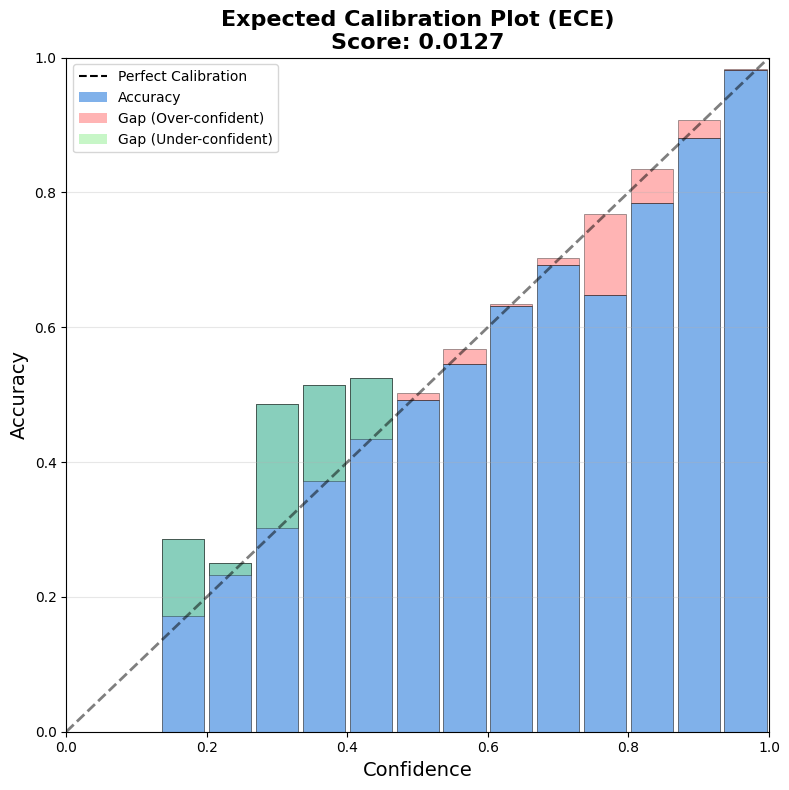

In [8]:
# Plot calibration curve
# plot_calibration_curve(bin_confidences, bin_accuracies, bin_counts, ece, num_bins=NUM_BINS)
plot_ece_curve(bin_confidences, bin_accuracies, bin_counts, ece, num_bins=NUM_BINS)

## Visualize Individual Predictions with Error Plots

Now let's visualize predictions for individual test images with error bars showing uncertainty.

### Visualize a Single Sample

Change the `sample_idx` to visualize different images from the batch (0-127).

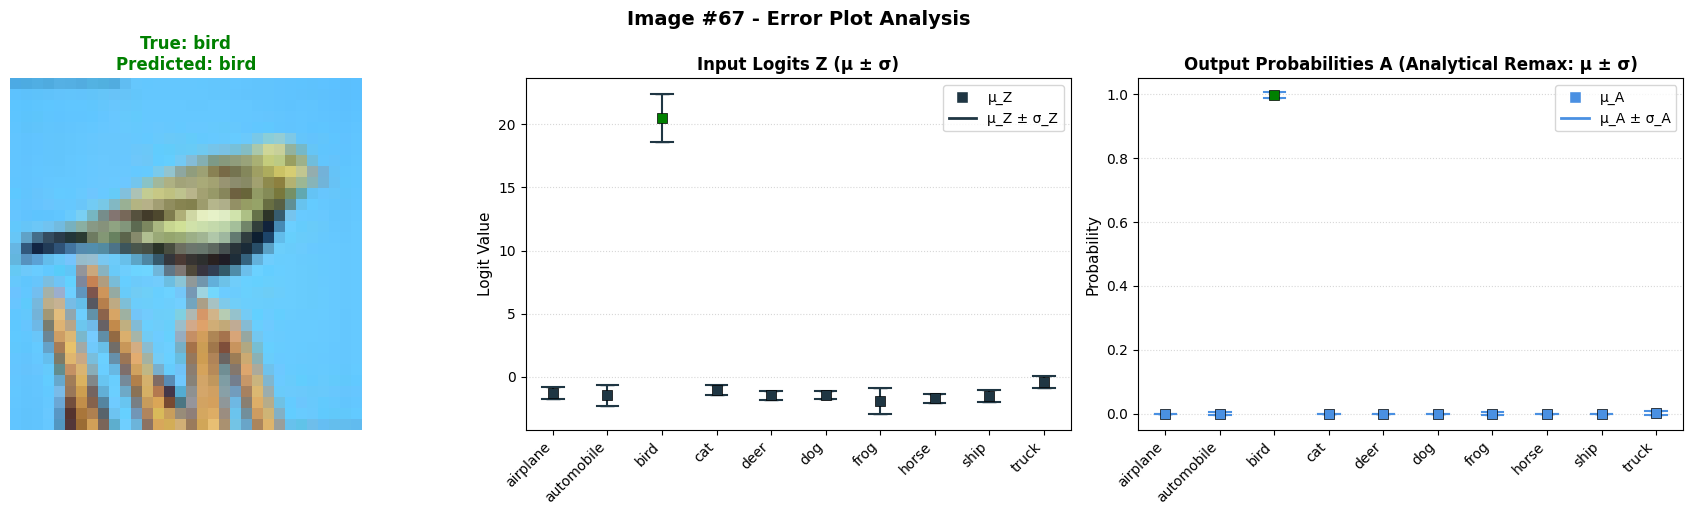


Image #67 Analysis
True Label: bird
Predicted Label: bird
Prediction Probability: 0.9964 ± 0.0090
True Class Probability: 0.9964 ± 0.0090
Entropy: 0.0271
Total Variance: 0.0002
Correct: ✓



In [15]:
# Visualize a specific image (change index to see different images)
sample_idx = 67

images = test_set.data
labels = test_set.targets


# Get image and predictions
img_tensor = images[sample_idx]
# print(img_tensor.shape) (3, 32, 32)
true_label = labels[sample_idx]
mu_z = mu_logits[sample_idx]
sigma_z_sq = var_logits[sample_idx]

# Plot with error bars
plot_error_bars(
    img_tensor, 
    true_label, 
    mu_z, 
    sigma_z_sq,
    image_idx=sample_idx
)

## Summary

This notebook demonstrates:
1. Loading a trained PyTAGI model from checkpoints
2. Evaluating the model on the CIFAR-10 test set
3. **Calculating Expected Calibration Error (ECE)** - a metric showing how well the model's confidence matches its accuracy
4. **Plotting a calibration curve** - visualizing the relationship between confidence and accuracy across different confidence bins
5. Visualizing predictions with error bar plots showing:
   - **Input Logits (Z)**: Mean and standard deviation of the model's raw outputs
   - **Output Probabilities (A)**: Mean and standard deviation after applying analytical Remax

**Calibration Metrics:**
- **ECE (Expected Calibration Error)**: Measures the difference between confidence and accuracy. Lower is better (0 = perfectly calibrated).
- **Calibration Plot**: Shows how well-calibrated the model is:
  - Points on the diagonal line indicate perfect calibration
  - Points above the line indicate over-confidence
  - Points below the line indicate under-confidence

You can modify the `CHECKPOINT_PATH` at the top to test different model checkpoints, or change the `sample_idx` to visualize different images.

## High Variance and Entropy Examples

The following sections visualize:
1. 5 examples with the highest total variance
2. 5 examples with the highest entropy

In [10]:
# Calculate total variance (sum across all classes) and entropy for each example
total_variance = var_probs.sum(axis=1)

# print(m_epistemic.shape) (128, 10)


# Calculate entropy
entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)

print(f"Total variance range: {total_variance.min():.4f} to {total_variance.max():.4f}")
print(f"Entropy range: {entropy.min():.4f} to {entropy.max():.4f}")

Total variance range: 0.0000 to 0.1844
Entropy range: -0.0000 to 2.2623


### 5 Examples with Highest Total Variance

Total Variance: 0.1844
Entropy: 1.3409
Logits: [-1.2628222  -2.236454    7.0522842  -1.4817572   3.2857609  -4.3296175
 -3.5750036   0.49561882 -3.9498625  -0.9836521 ]


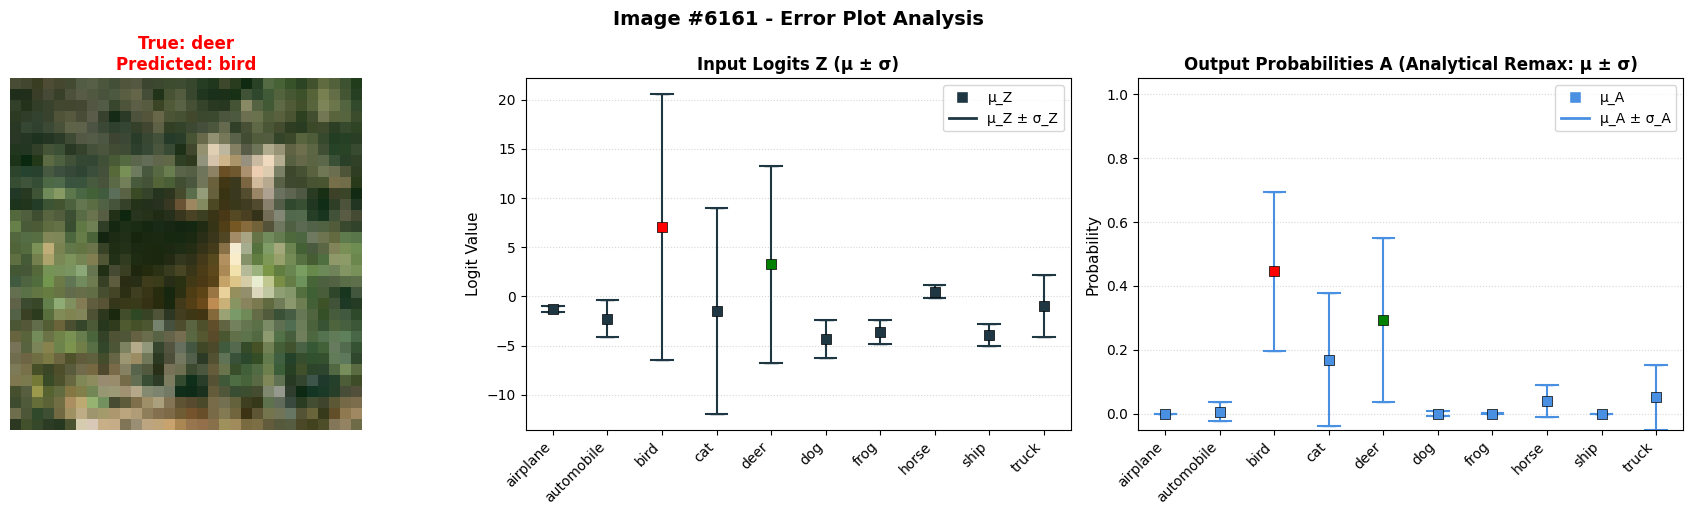


Image #6161 Analysis
True Label: deer
Predicted Label: bird
Prediction Probability: 0.4456 ± 0.2490
True Class Probability: 0.2938 ± 0.2567
Entropy: 1.3409
Total Variance: 0.1844
Correct: ✗

Total Variance: 0.1781
Entropy: 0.6808
Logits: [-123.16204 -313.15936 -202.9057   -45.71312 -380.3778  -340.88403
 -278.24536   19.69019 -415.90482   -9.0565 ]


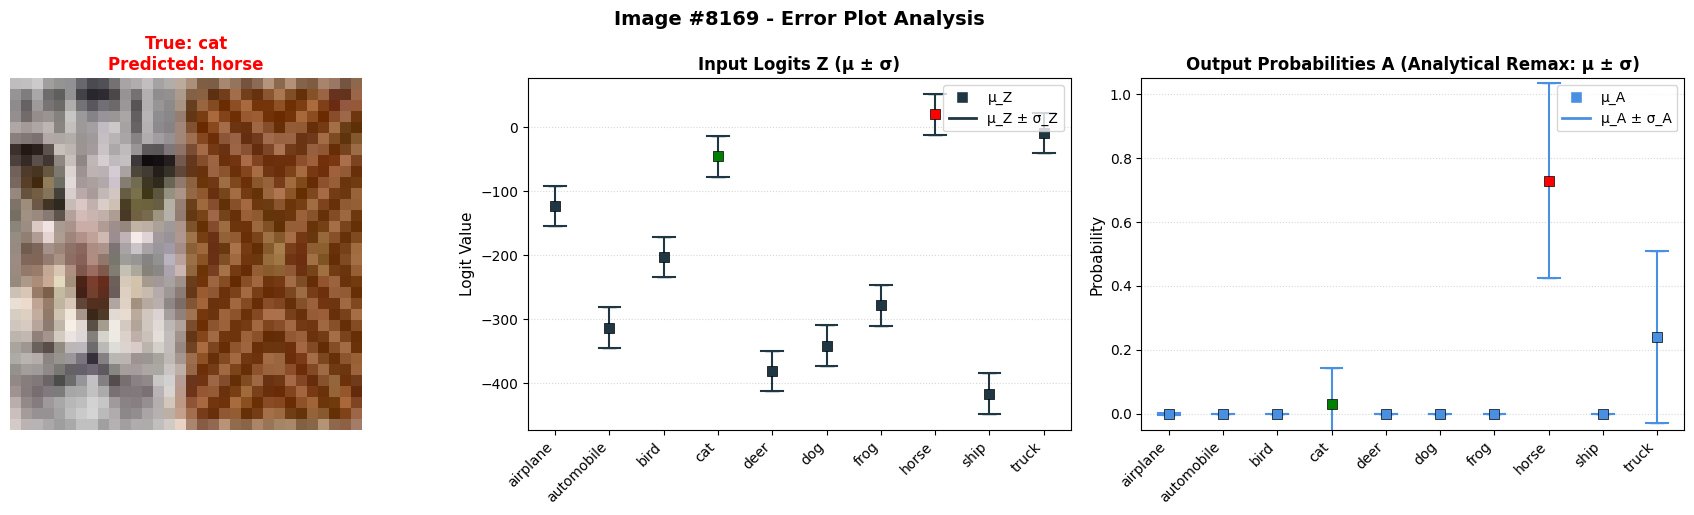


Image #8169 Analysis
True Label: cat
Predicted Label: horse
Prediction Probability: 0.7291 ± 0.3054
True Class Probability: 0.0310 ± 0.1132
Entropy: 0.6808
Total Variance: 0.1781
Correct: ✗

Total Variance: 0.1736
Entropy: 2.0193
Logits: [ -5.575039  -13.514302   16.331787   22.251362  -37.202606  -20.786533
 -24.326797  -23.801403   -3.3359127 -13.227704 ]


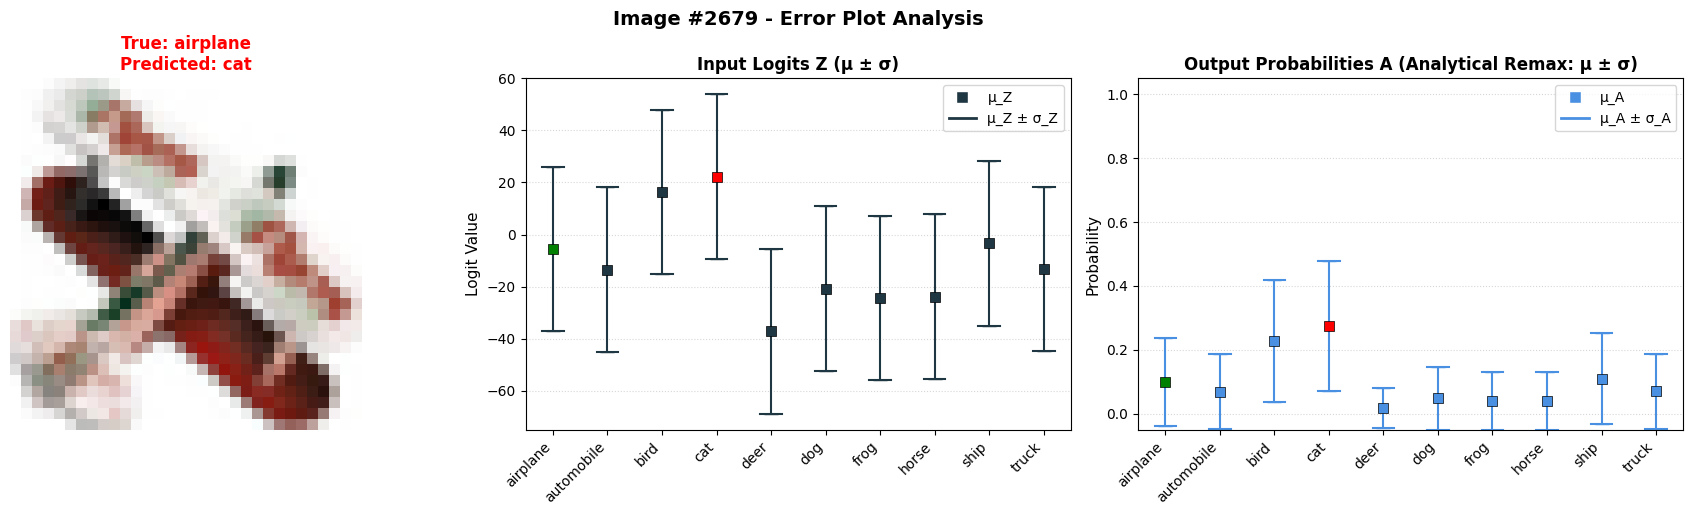


Image #2679 Analysis
True Label: airplane
Predicted Label: cat
Prediction Probability: 0.2738 ± 0.2028
True Class Probability: 0.0999 ± 0.1371
Entropy: 2.0193
Total Variance: 0.1736
Correct: ✗

Total Variance: 0.1602
Entropy: 1.7940
Logits: [ 0.82342243 -1.6081038   5.171399   -2.0534868   2.3754506  -2.4725084
 -3.036582    0.9983072  -0.5512676   1.7073135 ]


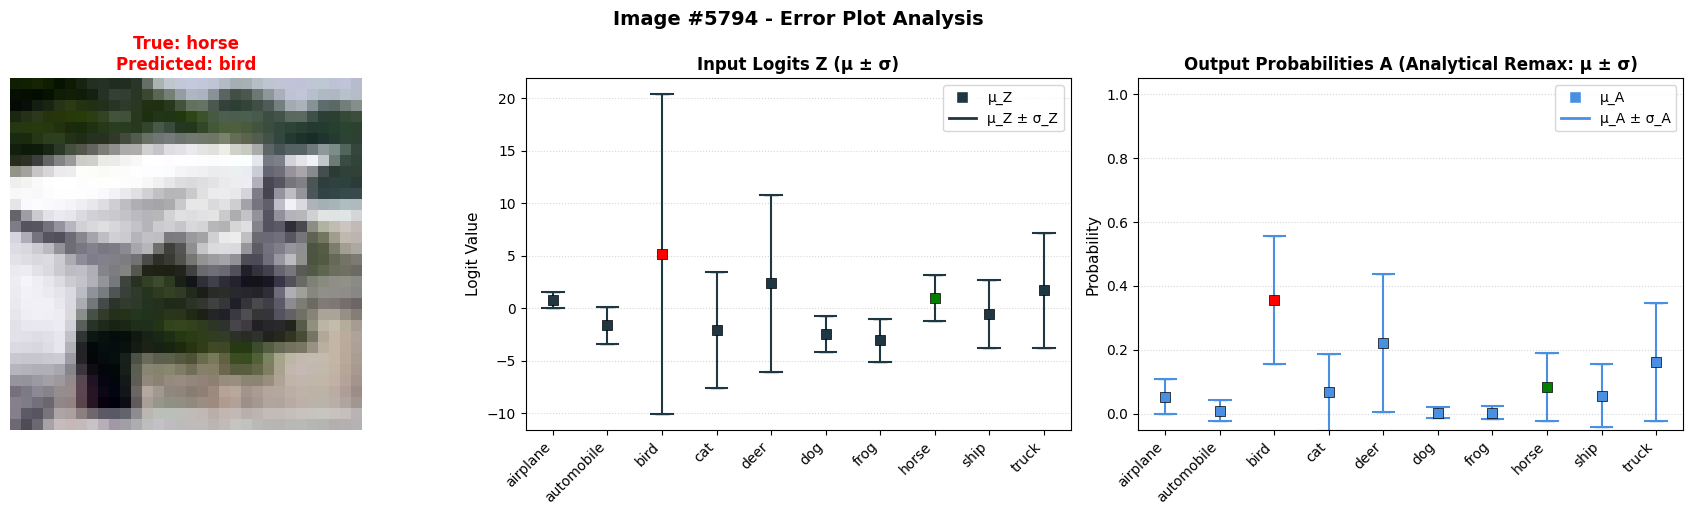


Image #5794 Analysis
True Label: horse
Predicted Label: bird
Prediction Probability: 0.3574 ± 0.2003
True Class Probability: 0.0842 ± 0.1052
Entropy: 1.7940
Total Variance: 0.1602
Correct: ✗

Total Variance: 0.1573
Entropy: 1.5666
Logits: [-1.8211861 -1.952754  10.508153  -5.5255795 -2.7163162 -2.7406988
  5.1209     0.8482952 -3.0553179  2.884521 ]


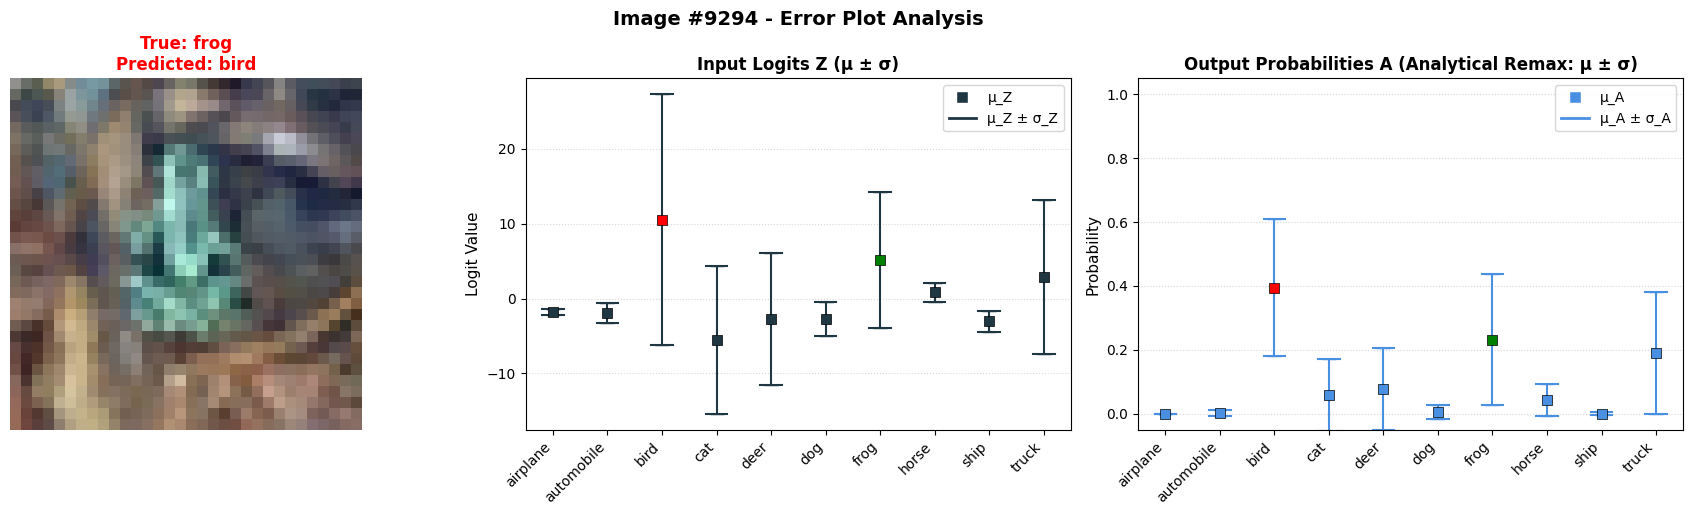


Image #9294 Analysis
True Label: frog
Predicted Label: bird
Prediction Probability: 0.3952 ± 0.2143
True Class Probability: 0.2323 ± 0.2059
Entropy: 1.5666
Total Variance: 0.1573
Correct: ✗



In [11]:
# print("
# === 5 EXAMPLES WITH HIGHEST TOTAL VARIANCE ===
# ")

# Get indices of top 5 highest total variance
top_var_indices = np.argsort(total_variance)[::-1][:5]

for i, idx in enumerate(top_var_indices):
    # print(f"
### Example {i+1} (Image #{idx}) ###")
    print(f"Total Variance: {total_variance[idx]:.4f}")
    print(f"Entropy: {entropy[idx]:.4f}")
    print("Logits:", mu_logits[idx])
    
    # Denormalize and plot
    img = images[idx]
    true_label = labels[idx]
    mu_z = mu_logits[idx]
    sigma_z_sq = var_logits[idx]
    
    plot_error_bars(img, true_label, mu_z, sigma_z_sq, image_idx=idx)

### 5 Examples with Highest Entropy

Top 10 Entropy Indices: [3445 5037 2249 1665 7701 6363 5798 6350 4817 6206]
Entropy Values: [2.26225572 2.21644922 2.17716096 2.17312562 2.16291423 2.15953903
 2.15200846 2.14355985 2.13579381 2.12862368]

 VISUALIZING TOP 10 HIGH ENTROPY IMAGES

Rank 1: Image #3445 | Entropy: 2.2623
Logits: [8.781458  1.6203775 2.4452682 6.884672  7.660339  0.6517601 1.1478586
 3.5793853 0.3336563 2.3276792]


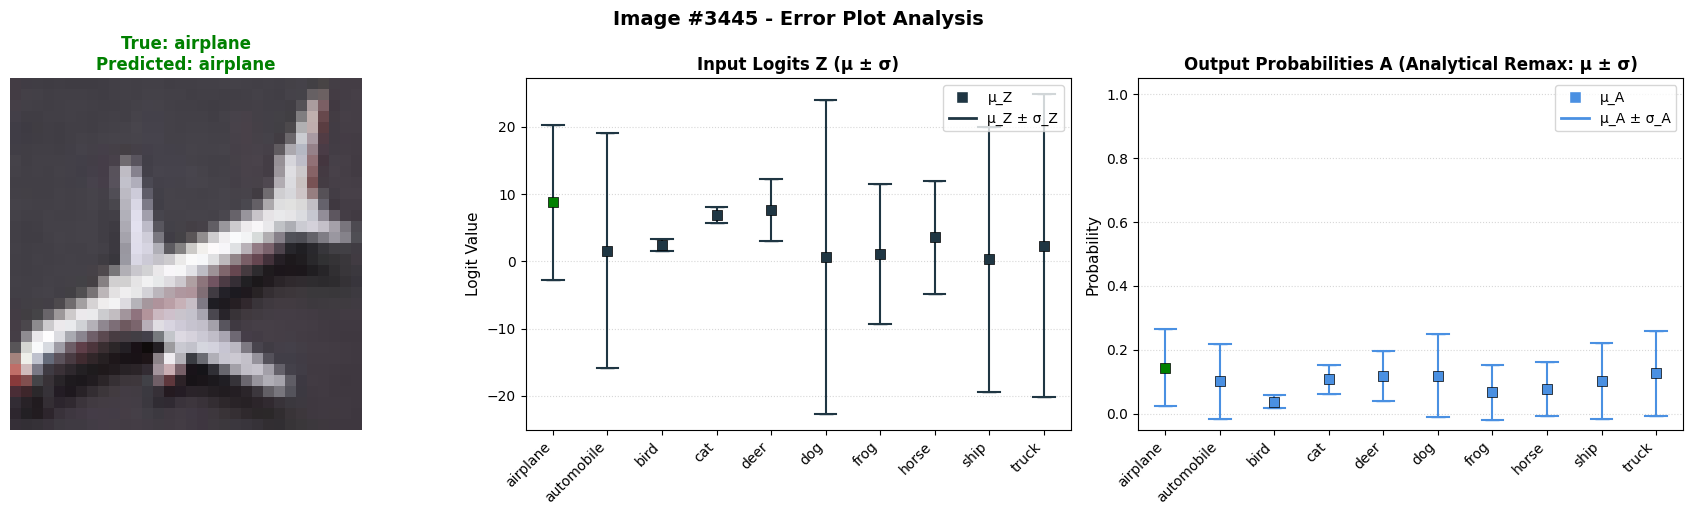


Image #3445 Analysis
True Label: airplane
Predicted Label: airplane
Prediction Probability: 0.1448 ± 0.1210
True Class Probability: 0.1448 ± 0.1210
Entropy: 2.2623
Total Variance: 0.1004
Correct: ✓

Rank 2: Image #5037 | Entropy: 2.2164
Logits: [ 3.9008327   0.3097458   0.6945858   5.0323505   7.569788   -1.051609
  0.0657835   2.2000918   0.03923035  1.1537466 ]


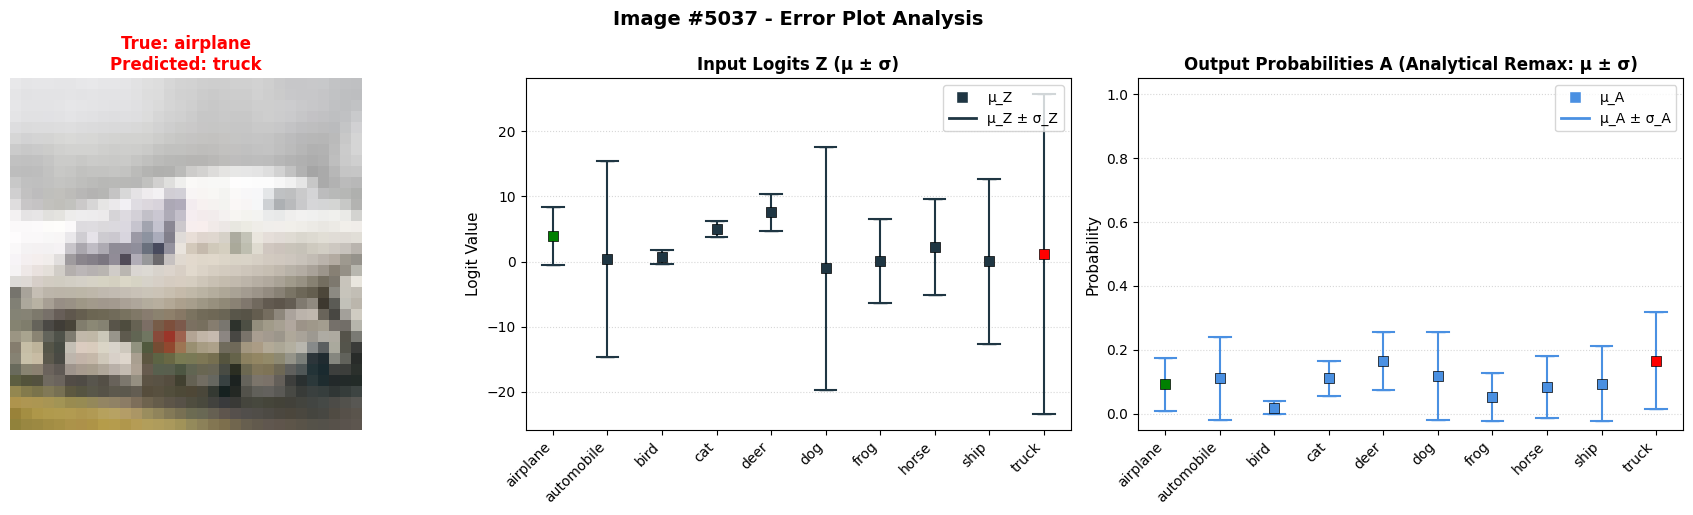


Image #5037 Analysis
True Label: airplane
Predicted Label: truck
Prediction Probability: 0.1664 ± 0.1526
True Class Probability: 0.0919 ± 0.0838
Entropy: 2.2164
Total Variance: 0.1064
Correct: ✗

Rank 3: Image #2249 | Entropy: 2.1772
Logits: [9.502828   0.12052536 1.2586889  3.6886744  5.187185   0.15826035
 0.7153349  2.0052862  0.22898006 1.8692198 ]


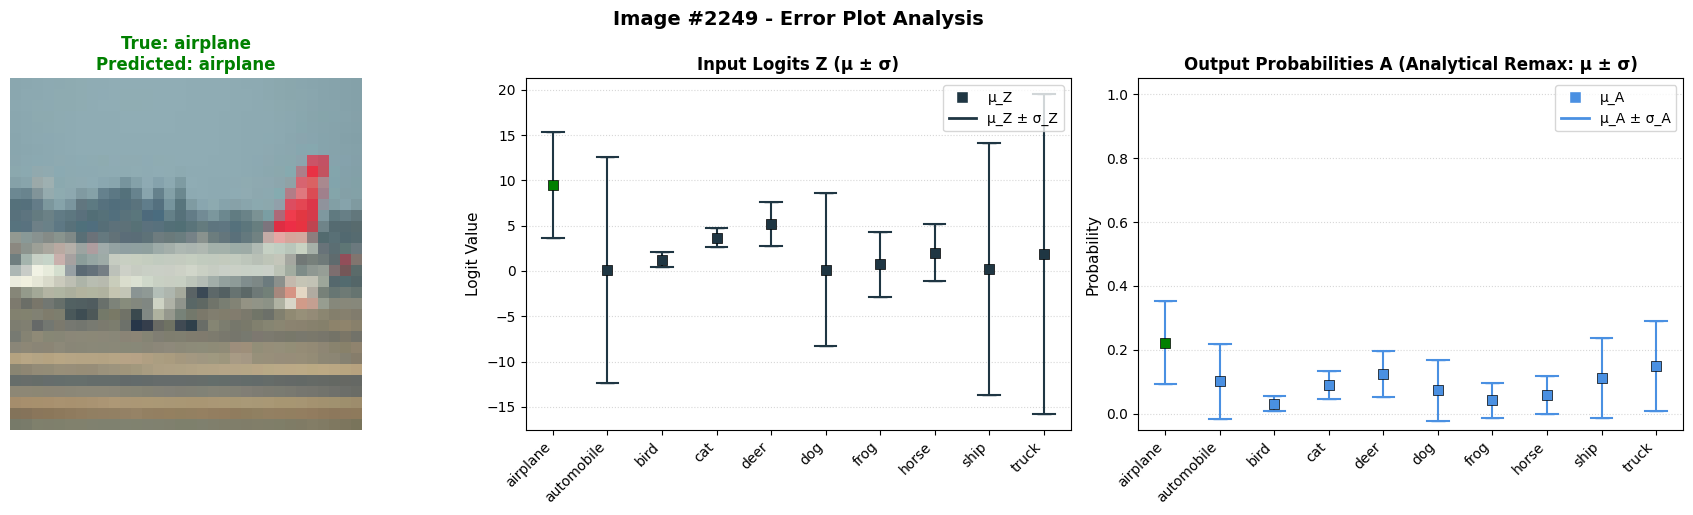


Image #2249 Analysis
True Label: airplane
Predicted Label: airplane
Prediction Probability: 0.2231 ± 0.1302
True Class Probability: 0.2231 ± 0.1302
Entropy: 2.1772
Total Variance: 0.0896
Correct: ✓

Rank 4: Image #1665 | Entropy: 2.1731
Logits: [-2.2107115  3.8029451 12.472495  11.081273   5.9547853  6.0427427
 18.492765   7.66642    0.2517662  1.5079403]


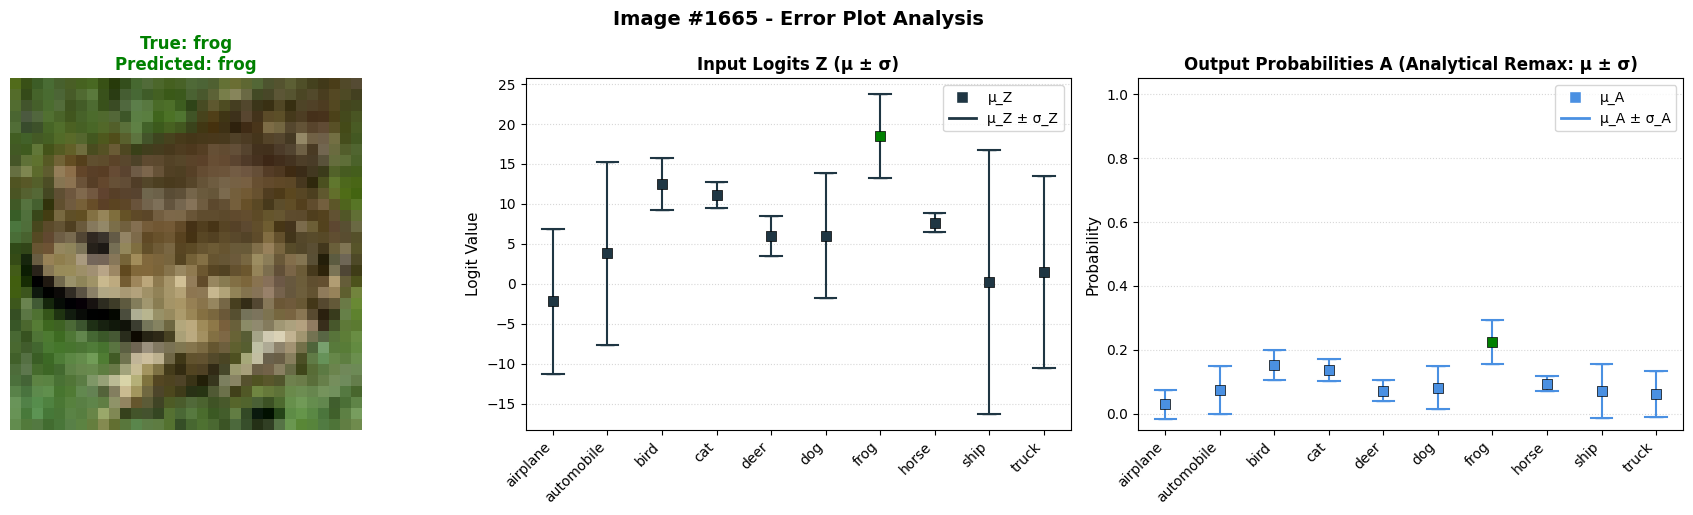


Image #1665 Analysis
True Label: frog
Predicted Label: frog
Prediction Probability: 0.2252 ± 0.0679
True Class Probability: 0.2252 ± 0.0679
Entropy: 2.1731
Total Variance: 0.0343
Correct: ✓

Rank 5: Image #7701 | Entropy: 2.1629
Logits: [5.2984867  1.6512156  0.3669405  5.0960617  7.65442    0.16230202
 0.09485149 3.047564   0.85802555 3.0133471 ]


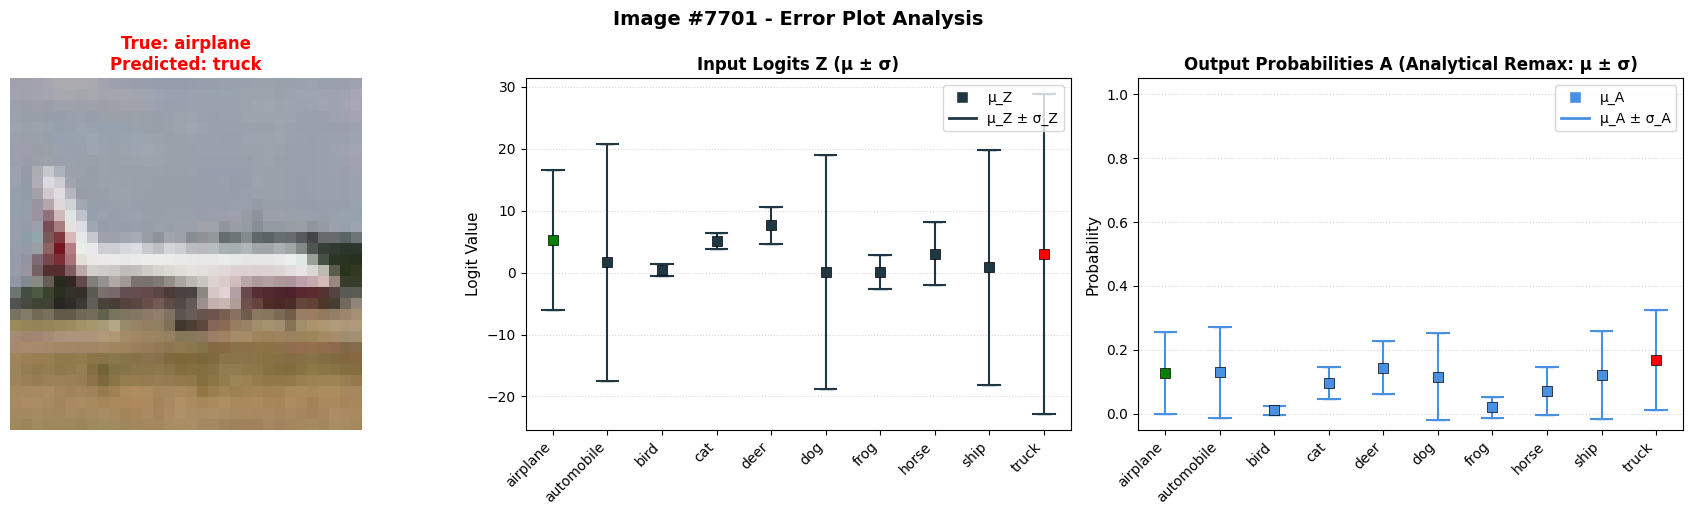


Image #7701 Analysis
True Label: airplane
Predicted Label: truck
Prediction Probability: 0.1692 ± 0.1563
True Class Probability: 0.1284 ± 0.1274
Entropy: 2.1629
Total Variance: 0.1139
Correct: ✗

Rank 6: Image #6363 | Entropy: 2.1595
Logits: [ 5.797827    0.1974926  -0.42630386  2.6547217   6.682216   -0.01185989
  0.31508732  2.3899026   0.74225616  2.2600784 ]


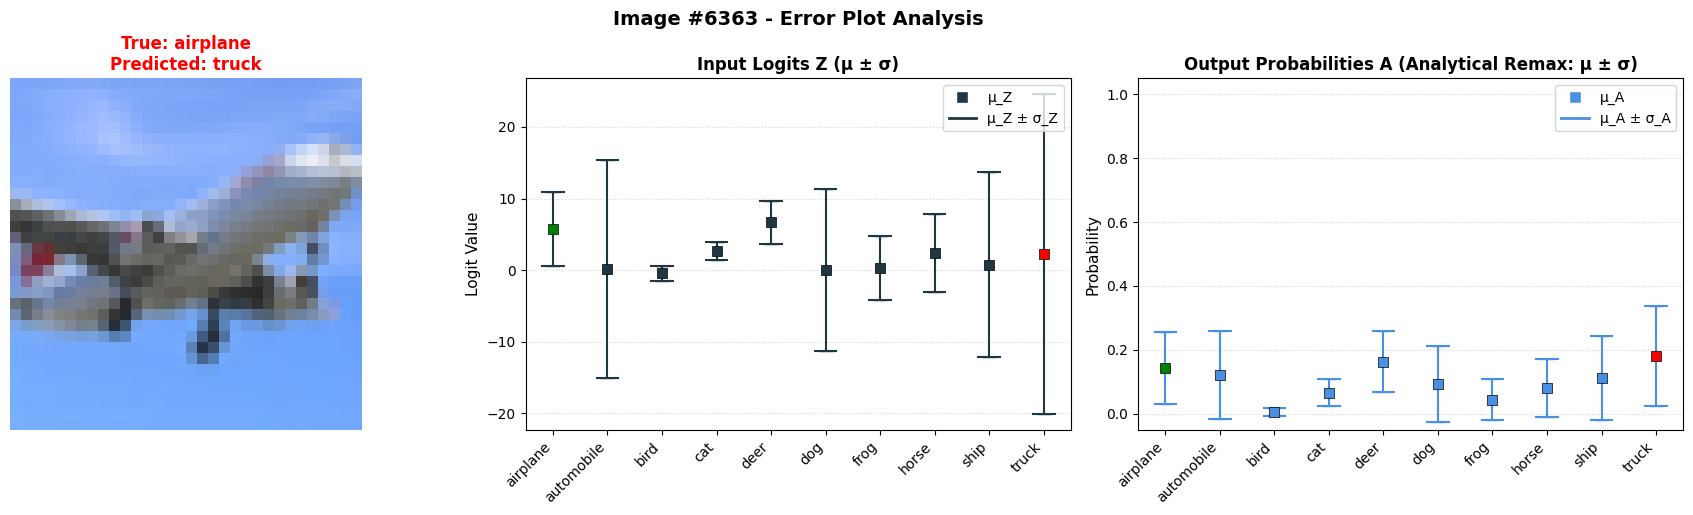


Image #6363 Analysis
True Label: airplane
Predicted Label: truck
Prediction Probability: 0.1806 ± 0.1566
True Class Probability: 0.1433 ± 0.1125
Entropy: 2.1595
Total Variance: 0.1103
Correct: ✗

Rank 7: Image #5798 | Entropy: 2.1520
Logits: [11.012585    0.6924877   0.5129318   4.420931    6.2809877   1.563756
  1.0062094   2.7014804   0.60033417  3.086998  ]


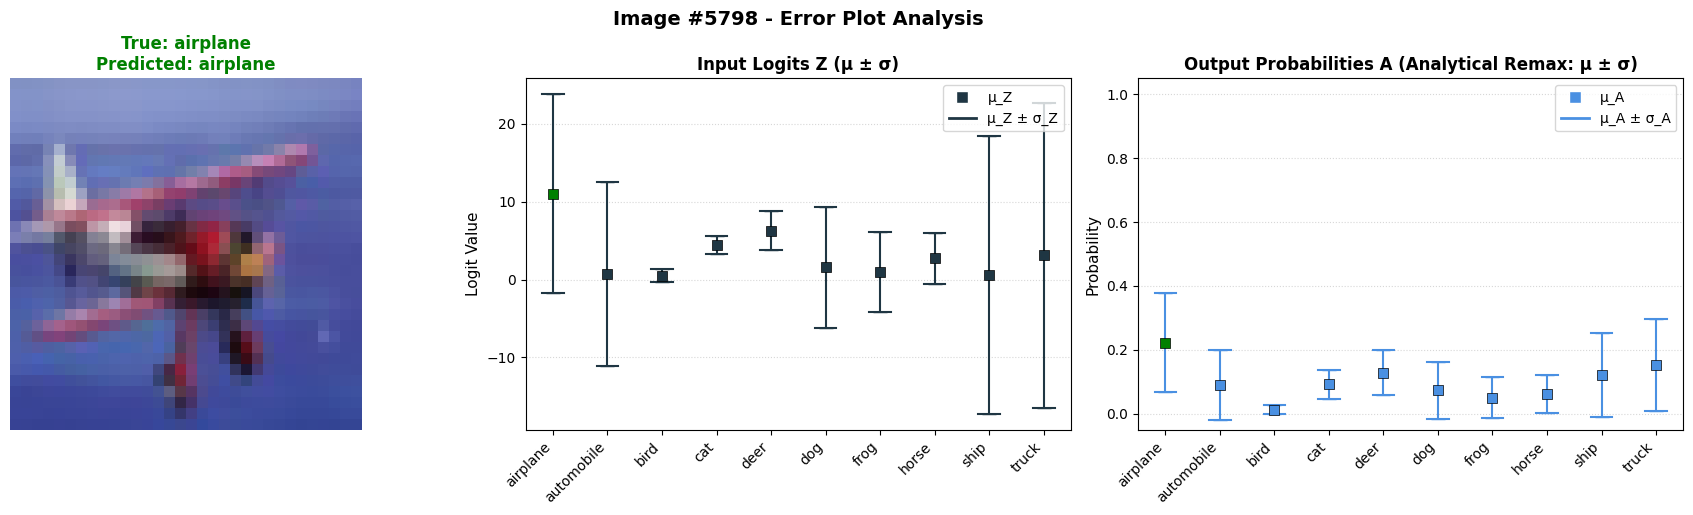


Image #5798 Analysis
True Label: airplane
Predicted Label: airplane
Prediction Probability: 0.2224 ± 0.1550
True Class Probability: 0.2224 ± 0.1550
Entropy: 2.1520
Total Variance: 0.0969
Correct: ✓

Rank 8: Image #6350 | Entropy: 2.1436
Logits: [ 1.9003439   0.88512135 -1.5423117   3.0711904   9.280766    0.6700325
  0.95249844  2.486846    1.1187906   3.374084  ]


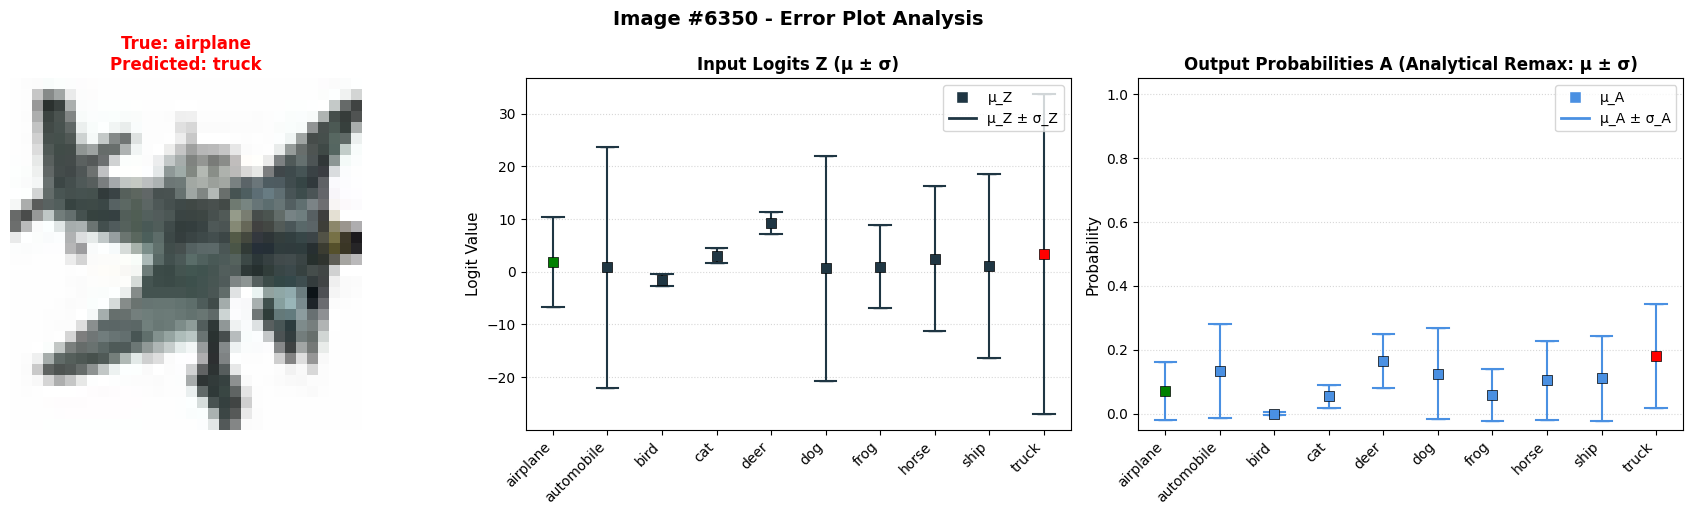


Image #6350 Analysis
True Label: airplane
Predicted Label: truck
Prediction Probability: 0.1810 ± 0.1628
True Class Probability: 0.0724 ± 0.0910
Entropy: 2.1436
Total Variance: 0.1247
Correct: ✗

Rank 9: Image #4817 | Entropy: 2.1358
Logits: [-2.0406008  3.7261262 -3.2922115  5.443729  13.919939   3.466878
  2.5348015  5.70337    2.7644634  7.029038 ]


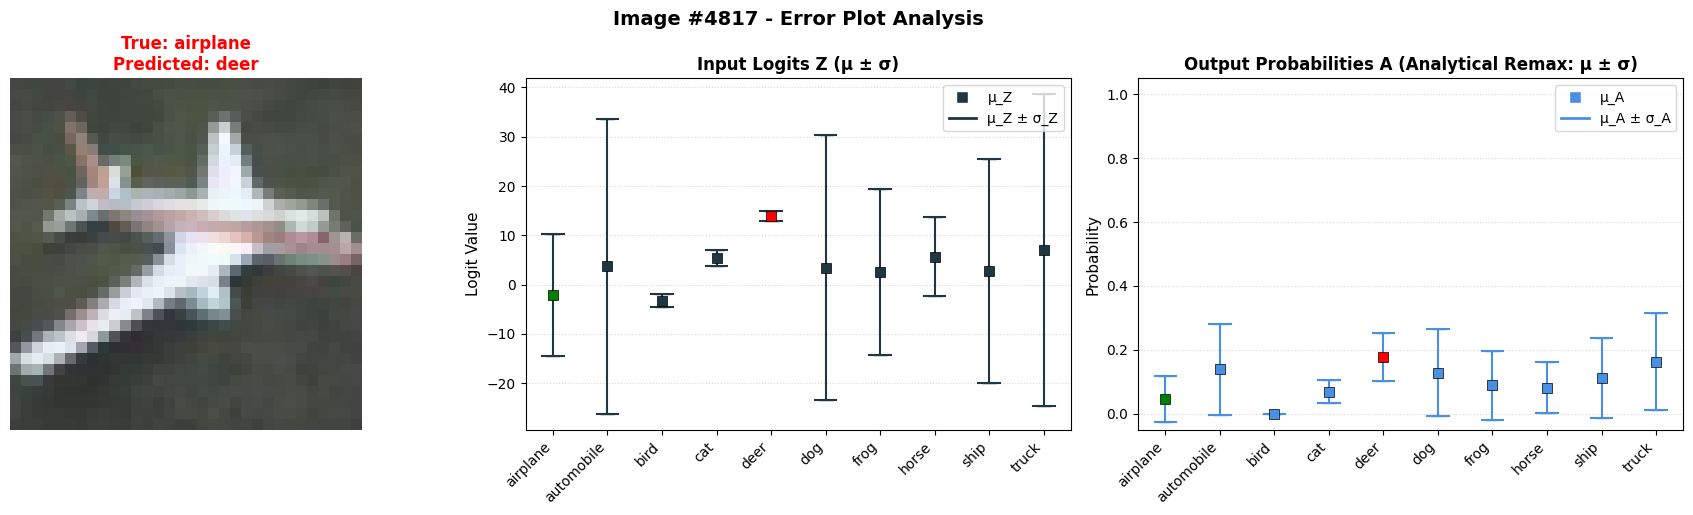


Image #4817 Analysis
True Label: airplane
Predicted Label: deer
Prediction Probability: 0.1783 ± 0.0756
True Class Probability: 0.0457 ± 0.0719
Entropy: 2.1358
Total Variance: 0.1074
Correct: ✗

Rank 10: Image #6206 | Entropy: 2.1286
Logits: [-0.6137352  -0.6626606  -0.45504665  2.5167336   4.3586483   4.4240904
  3.6431231   1.7529373   1.8435555   1.0195189 ]


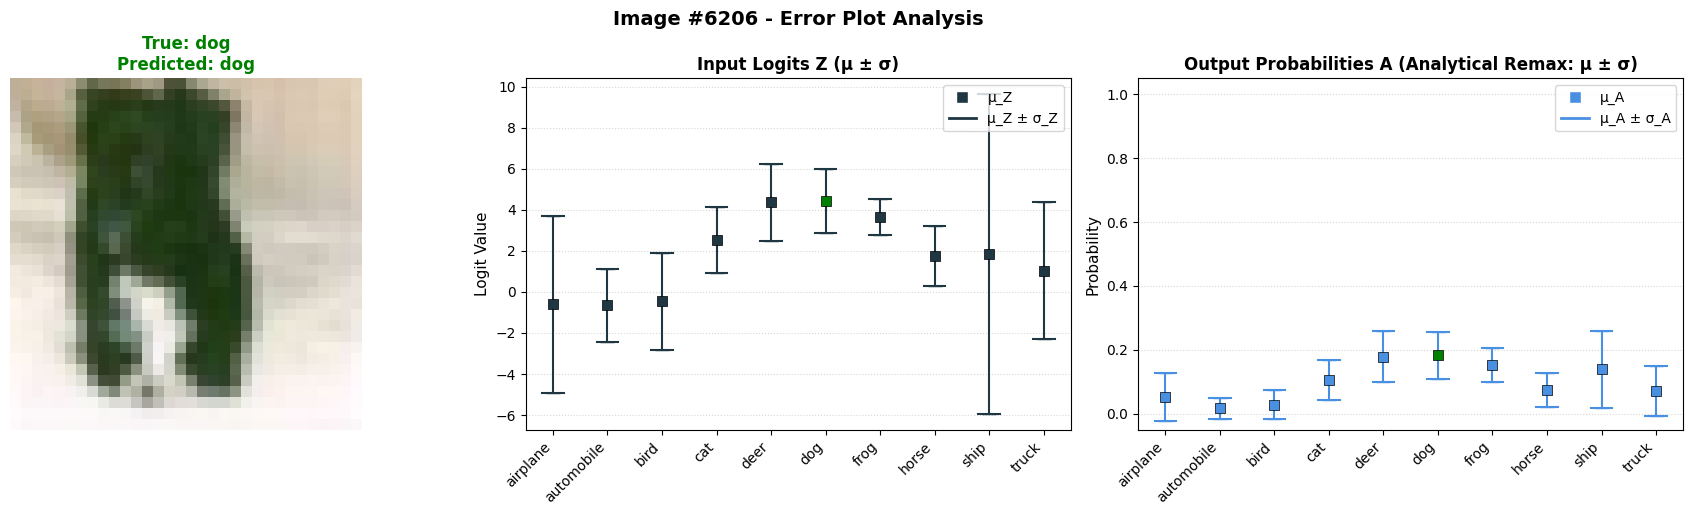


Image #6206 Analysis
True Label: dog
Predicted Label: dog
Prediction Probability: 0.1835 ± 0.0739
True Class Probability: 0.1835 ± 0.0739
Entropy: 2.1286
Total Variance: 0.0508
Correct: ✓



In [12]:
# 1. Calculate Probabilities and Entropy for the entire batch
entropies = []
all_probs = []

for i in range(len(mu_logits)):
    # Compute Entropy: H(p) = -sum(p * log(p))
    # Add epsilon to avoid log(0)
    epsilon = 1e-12
    entropy = -np.sum(probs[i] * np.log(probs[i] + epsilon))
    entropies.append(entropy)

entropies = np.array(entropies)

# 2. Find the indices of the top 5 images with the highest entropy
top_5_indices = np.argsort(entropies)[::-1][:10]

print(f"Top 10 Entropy Indices: {top_5_indices}")
print(f"Entropy Values: {entropies[top_5_indices]}")

# 3. Plot the top 5 images
print("\n" + "="*40)
print(" VISUALIZING TOP 10 HIGH ENTROPY IMAGES")
print("="*40 + "\n")

for rank, idx in enumerate(top_5_indices):
    print(f"Rank {rank+1}: Image #{idx} | Entropy: {entropies[idx]:.4f}")
    print("Logits:", mu_logits[idx])
    
    # Prepare data for plotting
    # Assuming 'images' and 'label_batch' are available from your previous cells
    img_tensor = images[idx]
                
    # Use the existing plot function
    plot_error_bars(
        image=img_tensor,
        true_label=labels[idx],
        mu_z=mu_logits[idx],
        sigma_z_sq=var_logits[idx],
        image_idx=idx
    )